In [1]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="darkgrid")

# Load dataset
iris = sns.load_dataset("iris")

# Preview dataset
print("Dataset:")
print(iris.head())
print(iris.tail())
print(iris.info())
print(iris.describe(include="all"))
print("Shape:", iris.shape)
print("Size:", iris.size)
print("Dimensions:", iris.ndim)
print("Columns:", iris.columns)
print("Data Types:\n", iris.dtypes)

Dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0 


Feature Types:
sepal_length: Numeric (float64)
sepal_width: Numeric (float64)
petal_length: Numeric (float64)
petal_width: Numeric (float64)
species: Nominal (object)


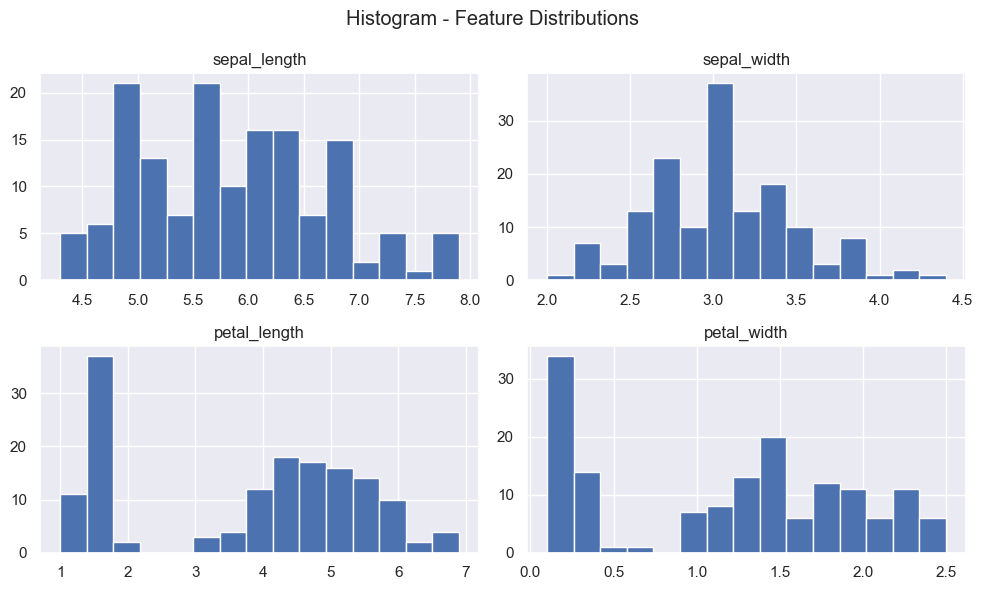

In [2]:
# 1. Feature Types
print("\nFeature Types:")
for column in iris.columns:#Runs code for every column.
    dtype = iris[column].dtype#Gets datatype of current column.
    ftype = "Nominal" if dtype == "object" else "Numeric"
    print(f"{column}: {ftype} ({dtype})")

# 2. Histograms
iris_numeric = iris.drop(columns='species')#Histogram works best on numeric data.
#frequency distribution
iris_numeric.hist(bins=15, figsize=(10, 6))#Creates histograms for all numeric columns.
plt.suptitle("Histogram - Feature Distributions")
plt.tight_layout()
plt.show()
#Sepal Length
#Mostly centered around medium values.
#Sepal Width
#Some spread and slight skewness.
#Petal Length
#Wide distribution because species differ a lot
#Petal Width
#Clear grouping visible.

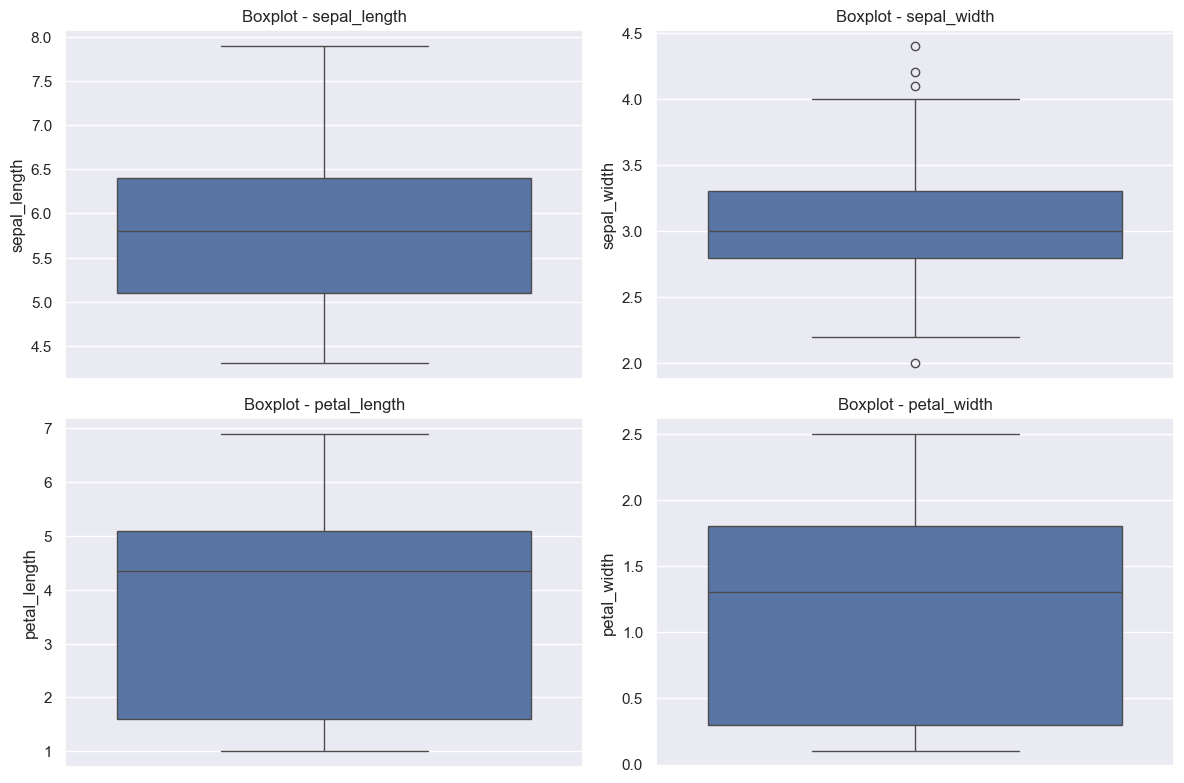

In [3]:
# 3. Boxplots
plt.figure(figsize=(12, 8))
for i, col in enumerate(iris_numeric.columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=iris[col])
    plt.title(f"Boxplot - {col}")
plt.tight_layout()
plt.show()
#Sepal Width
#Usually shows outliers.
#Petal Length & Width
#Wider spread due to different flower species.

In [4]:
# 4. Observations
print("\nObservations & Inference:")

# Descriptive stats
print("\nDescriptive Statistics:")
print(iris_numeric.describe())

# Outliers using IQR
print("\nOutliers (using IQR):")
for column in iris_numeric.columns:#Checks every numeric feature.
    Q1 = iris[column].quantile(0.25)#25th percentile.
#25% data lies below this.
    Q3 = iris[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = iris[(iris[column] < lower) | (iris[column] > upper)]
    print(f"{column}: {len(outliers)} outlier(s)")#Counts total outliers.
    #Interquartile Range.
#Measures spread of middle 50% data.
#Formula:
#IQR=Q3−Q1
#Calculates normal data limits.Anything outside:lower limit upper limit is treated as outlier.


Observations & Inference:

Descriptive Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Outliers (using IQR):
sepal_length: 0 outlier(s)
sepal_width: 4 outlier(s)
petal_length: 0 outlier(s)
petal_width: 0 outlier(s)
